In [2]:
# Smart Agriculture Disease Advisor

## Data Preprocessing

### Objective

#This notebook prepares the PlantVillage dataset for deep learning by:

#- Loading the dataset
#- Creating TensorFlow datasets
#- Resizing images
#- Normalizing pixel values
#- Applying data augmentation
#- Optimizing the data pipeline for training

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [11]:
train_path = "plantvillage/PlantVillage/train"
val_path = "plantvillage/PlantVillage/val"

In [8]:
import os

print(os.listdir("/content"))

['.config', 'archive (1).zip', 'sample_data']


In [13]:
!kaggle datasets download -d mohitsingh1804/plantvillage
!unzip -q plantvillage.zip -d /content/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
plantvillage.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/plantvillage/PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
!rm -f "/content/archive (1).zip"

In [19]:
!kaggle datasets download -d mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
plantvillage.zip: Skipping, found more recently modified local copy (use --force to force download)


In [31]:
!unzip -oq plantvillage.zip -d /content/plantvillage

In [32]:
import os

print(os.listdir("/content/plantvillage"))
print(os.listdir("/content/plantvillage/PlantVillage"))

['PlantVillage']
['val', 'train']


In [33]:
train_path = "/content/plantvillage/PlantVillage/train"
val_path = "/content/plantvillage/PlantVillage/val"

In [34]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [35]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 43444 files belonging to 38 classes.


In [36]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 10861 files belonging to 38 classes.


In [37]:
class_names = train_ds.class_names

print("Total Classes:", len(class_names))
print(class_names)

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

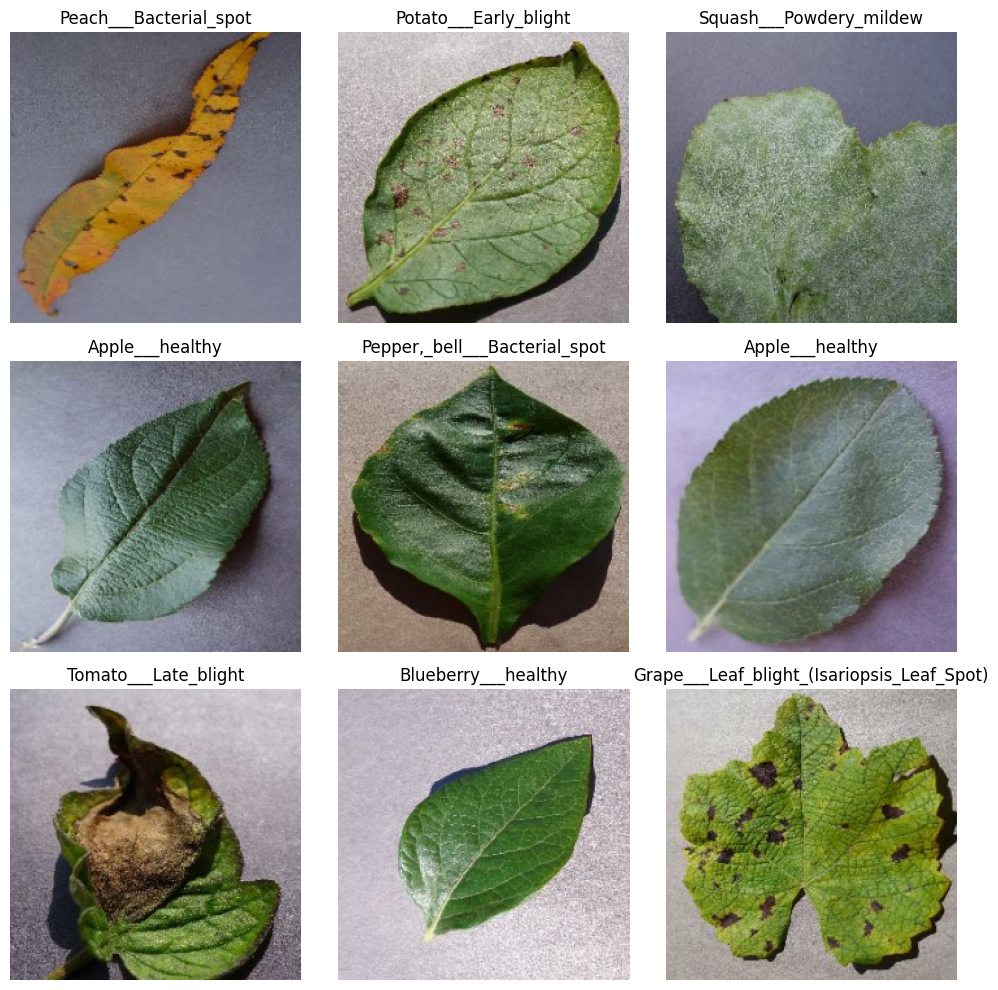

In [38]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [40]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [41]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [42]:
## Conclusion :In this notebook, the PlantVillage dataset was successfully preprocessed using TensorFlow. The images were resized to 224×224 pixels, normalized to a 0–1 range, and organized into efficient training and validation datasets. Data augmentation techniques, including random flipping, rotation, and zooming, were applied to improve the model's ability to generalize. Finally, the TensorFlow data pipeline was optimized using caching and prefetching, making the dataset ready for CNN model training.